## Step 1: Setup
Installing libraries and importing what I need. Setting device to GPU if available, else CPU.

In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
# importing required libraries
import torch
import numpy as np
import pandas as pd

In [24]:
# checking for gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Step 2: Load model and tokenizer
Loading pretrained GPT-2 small.
This is original, full-precision model - I'll quantize a copy of it later.

In [25]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# name of the model
model_name = "gpt2" # correspons to the small 124M version
# loading the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

In [26]:
# initializing the model
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [27]:
# evaluation mode
# not training mode
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

## Step 3: Calibration data
Loading ptb_text_only dataset and picking a small set of text samples.
This is the input I'll run through the model to observe its layer activations.

In [28]:
from datasets import load_dataset

# downloading and loading the dataset
dataset = load_dataset("sh0416/ag_news")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})


In [29]:
# picking the train part
train_ds = dataset['train']
print(train_ds.shape)

(120000, 3)


In [30]:
# checking some randow rows
# checking texts
for i in range(5,10):
  print(train_ds[i])

{'label': 3, 'title': 'Stocks End Up, But Near Year Lows (Reuters)', 'description': 'Reuters - Stocks ended slightly higher on Friday\\but stayed near lows for the year as oil prices surged past  #36;46\\a barrel, offsetting a positive outlook from computer maker\\Dell Inc. (DELL.O)'}
{'label': 3, 'title': 'Money Funds Fell in Latest Week (AP)', 'description': "AP - Assets of the nation's retail money market mutual funds fell by  #36;1.17 billion in the latest week to  #36;849.98 trillion, the Investment Company Institute said Thursday."}
{'label': 3, 'title': 'Fed minutes show dissent over inflation (USATODAY.com)', 'description': 'USATODAY.com - Retail sales bounced back a bit in July, and new claims for jobless benefits fell last week, the government said Thursday, indicating the economy is improving from a midsummer slump.'}
{'label': 3, 'title': 'Safety Net (Forbes.com)', 'description': 'Forbes.com - After earning a PH.D. in Sociology, Danny Bazil Riley started to work as the gene

In [31]:
# checking sentence length of first 20 rows
# description length
for i in range(20):
  print(f"{i}. {len(train_ds[i]['description'])}")

0. 94
1. 214
2. 184
3. 195
4. 160
5. 195
6. 178
7. 197
8. 390
9. 107
10. 199
11. 233
12. 159
13. 226
14. 225
15. 127
16. 120
17. 219
18. 123
19. 121


## Tokenizing calibration data
Tokenizing all 20 calibration samples together in one batch call, so padding works correctly (pads everyone to match the longest sample in this batch). Moving input_ids and attention_mask to device.

In [32]:
# building calibration sample
# as a list of first 20 rows (description)
calibration_sample = [row for row in train_ds['description'][:20]]
# adding pad token
tokenizer.pad_token = tokenizer.eos_token
# tokenizing
inputs = tokenizer(calibration_sample,return_tensors="pt",padding=True,truncation=True)

In [33]:
# checking input_ids and attention mask
# from inputs
input_ids = inputs['input_ids'].to(device)
attention_mask = inputs['attention_mask'].to(device)

In [34]:
# shape of them
print(input_ids.shape)
print(attention_mask.shape)

torch.Size([20, 91])
torch.Size([20, 91])


In [35]:
print(input_ids)

tensor([[12637,   532, 10073,  ..., 50256, 50256, 50256],
        [12637,   532, 15348,  ..., 50256, 50256, 50256],
        [12637,   532,  1406,  ..., 50256, 50256, 50256],
        ...,
        [ 1858,   318,  1310,  ..., 50256, 50256, 50256],
        [  464,  1294,  3292,  ..., 50256, 50256, 50256],
        [44142,  6175, 17537,  ..., 50256, 50256, 50256]], device='cuda:0')


In [36]:
print(attention_mask)

tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]], device='cuda:0')


## Step 4: 4-bit per-channel quantization function
Writing a function that quantizes a weight matrix to 4-bit, per output channel (row), then dequantizes it back to float.
Each row gets its own scale, instead of one scale for the whole matrix - this should give better precision than a single global scale.

In [37]:
n = 7 # because of 4 bit

def per_channel_quantization(weights):
  dequantized_weights = [] # storing all the dequantized weights. same shape as original

  for row in weights:
    max_weight = row.abs().max()

    if max_weight==0:
      dequantized_weights.append(row.clone())
      continue

    scaling_factor = max_weight/n
    quantized = torch.round(row/scaling_factor).clamp(-n,n)
    dequantized = quantized*scaling_factor
    dequantized_weights.append(dequantized)

  matrix = torch.stack(dequantized_weights)
  return matrix

## Testing the quantization function
Testing per_channel_quantization on a small 3x3 tensor before applying it to the real model.
Checking: a row with clear range, a row with small uniform values, and an all-zero row (to confirm the zero-guard works).

In [38]:
# testing the function
# to see if it's correctly working
test_tensor = torch.tensor([[1.0, 2.0, 8.0], [0.1, 0.1, 0.1], [0.0, 0.0, 0.0]])
print(per_channel_quantization(test_tensor))

tensor([[1.1429, 2.2857, 8.0000],
        [0.1000, 0.1000, 0.1000],
        [0.0000, 0.0000, 0.0000]])


## Step 5: Quantized copy of the model
Making a deep copy of the original model, then replacing every nn.Linear layer's weight with its per-channel quantized-dequantized version.

In [39]:
import copy
from transformers.pytorch_utils import Conv1D

model_copy = copy.deepcopy(model)
count = 0 # counter for sanity check
# running a loop
# quantizing the weights
for name,layer in model_copy.named_modules():
  if isinstance(layer,(torch.nn.Linear, Conv1D)):
    count+=1
    weight_matrix = layer.weight.data
    quantized_weight_matrix = per_channel_quantization(weight_matrix)

    with torch.no_grad():
      layer.weight.data = quantized_weight_matrix

print(f"Quantized {count} layers")

Quantized 49 layers


## Step 6: Forward hooks
Registering a forward hook on every Linear/Conv1D layer in both models.
Each hook saves that layer's output whenever a forward pass runs - this is how I'll capture activations to compare later.

In [40]:
# now running the forward hooks
# for both original and quantized model
# creating two dictionaries to hold the activations
original_activations = {}
quantized_activations = {}

def get_activation_hook(storage_dict, layer_name):
  def hook(module, input, output):
    storage_dict[layer_name] = output.detach()
  return hook

# loop through all layers of original model and register the hook
hook_handles = []
for name, layer in model.named_modules():
  if isinstance(layer, (torch.nn.Linear, Conv1D)):
    handle = layer.register_forward_hook(get_activation_hook(original_activations, name))
    hook_handles.append(handle)

# loop through all layers of quantized model copy and register the hook
for name, layer in model_copy.named_modules():
  if isinstance(layer, (torch.nn.Linear, Conv1D)):
    handle = layer.register_forward_hook(get_activation_hook(quantized_activations, name))
    hook_handles.append(handle)

In [42]:
# now running a forward pass
with torch.no_grad():
  outputs = model(input_ids, attention_mask=attention_mask)
  print("Original model forward pass complete")

  outputs = model_copy(input_ids, attention_mask=attention_mask)
  print("Quantized model forward pass complete")

Original model forward pass complete
Quantized model forward pass complete


In [43]:
# sanity check
# length
print(len(original_activations))
print(len(quantized_activations))

49
49


In [44]:
# free-up the memory
for handle in hook_handles:
  handle.remove()

## Step 7: Per-layer reconstruction error
Comparing original_activations vs quantized_activations for each layer.
Using MSE: squaring the difference between original and quantized output, then averaging.

In [47]:
mse_error = {} # storing the per-layer reconstruction error

for name,layer in model.named_modules():
  if isinstance(layer,(torch.nn.Linear, Conv1D)):
    original_output = original_activations[name]
    quantized_output = quantized_activations[name]

    error = torch.mean((original_output - quantized_output)**2)
    mse_error[name] = error.item()

In [48]:
# now for sanity check
for name, err in mse_error.items():
    print(f"{name:40s} MSE = {err:.6f}")

transformer.h.0.attn.c_attn              MSE = 0.053399
transformer.h.0.attn.c_proj              MSE = 0.199809
transformer.h.0.mlp.c_fc                 MSE = 0.337952
transformer.h.0.mlp.c_proj               MSE = 0.578354
transformer.h.1.attn.c_attn              MSE = 0.159691
transformer.h.1.attn.c_proj              MSE = 0.295450
transformer.h.1.mlp.c_fc                 MSE = 0.288576
transformer.h.1.mlp.c_proj               MSE = 1.390043
transformer.h.2.attn.c_attn              MSE = 0.371191
transformer.h.2.attn.c_proj              MSE = 0.165121
transformer.h.2.mlp.c_fc                 MSE = 0.472657
transformer.h.2.mlp.c_proj               MSE = 2.766119
transformer.h.3.attn.c_attn              MSE = 0.699580
transformer.h.3.attn.c_proj              MSE = 0.110277
transformer.h.3.mlp.c_fc                 MSE = 0.361374
transformer.h.3.mlp.c_proj               MSE = 0.758752
transformer.h.4.attn.c_attn              MSE = 0.844527
transformer.h.4.attn.c_proj              MSE = 0

## Step 8: Visualizing per-layer reconstruction error
Bar chart of MSE per layer, to see the pattern across depth and layer type.

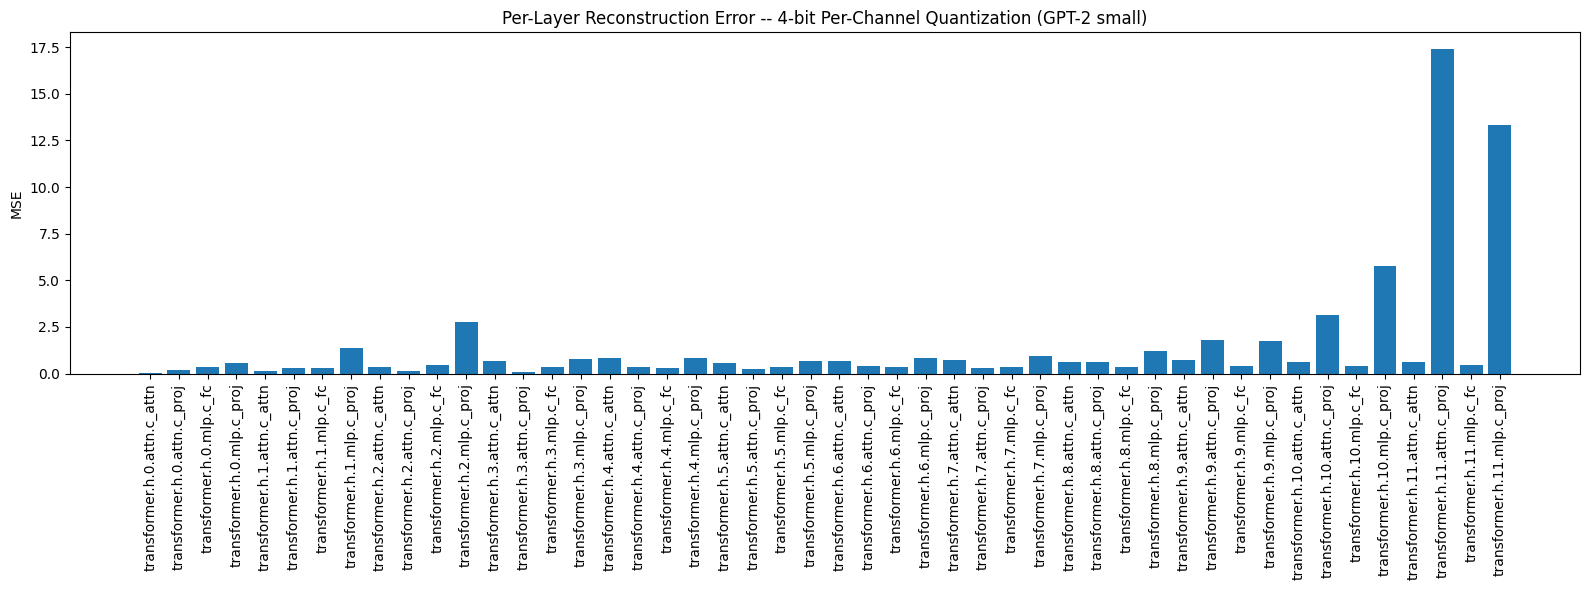

lm_head MSE = 1891.56 (excluded from chart above, shown separately for scale)


In [49]:
import matplotlib.pyplot as plt

# separating lm_head since its error is much larger than the rest
layer_names = [name for name in mse_error.keys() if name != "lm_head"]
layer_values = [mse_error[name] for name in layer_names]

# plotting main transformer layers
plt.figure(figsize=(16, 6))
plt.bar(range(len(layer_names)), layer_values)
plt.xticks(range(len(layer_names)), layer_names, rotation=90)
plt.ylabel("MSE")
plt.title("Per-Layer Reconstruction Error -- 4-bit Per-Channel Quantization (GPT-2 small)")
plt.tight_layout()
plt.show()

# printing lm_head separately since it's much larger in scale
print(f"lm_head MSE = {mse_error['lm_head']:.2f} (excluded from chart above, shown separately for scale)")